In [1]:
pip install jupyterlab xgboost pandas numpy scikit-learn matplotlib seaborn imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re, glob, os, warnings
warnings.filterwarnings('ignore')
 
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
 
print("All imports done")
 

All imports done


In [3]:
DATA_PATH      = "anticheat_project/data/DatasetCheating/Sessions"
VALID_SESSIONS = ['Session_1', 'Session_2']
 
def load_all_sessions(data_path):
    all_server  = []
    all_clients = []
 
    for session in sorted(os.listdir(data_path)):
        if session not in VALID_SESSIONS:
            print(f"  Skipping {session}")
            continue
 
        session_path = os.path.join(data_path, session)
        if not os.path.isdir(session_path): continue
 
        for match in sorted(os.listdir(session_path)):
            match_path = os.path.join(session_path, match)
            if not os.path.isdir(match_path): continue
 
            server_folder = os.path.join(match_path, "Server")
            if os.path.isdir(server_folder):
                for f in glob.glob(os.path.join(server_folder, "*.csv")):
                    if 'merged' in f.lower(): continue
                    df = pd.read_csv(f, low_memory=False)
                    df['session'] = session
                    df['match']   = match
                    df['source']  = os.path.basename(f)
                    all_server.append(df)
                    print(f" {session}/{match} server loaded")
 
            client_folder = os.path.join(match_path, "Clients")
            if os.path.isdir(client_folder):
                for f in glob.glob(os.path.join(client_folder, "*.csv")):
                    if 'merged' in f.lower(): continue
                    df = pd.read_csv(f, low_memory=False)
                    df['session'] = session
                    df['match']   = match
                    df['source']  = os.path.basename(f)
                    all_clients.append(df)
 
    server_df = pd.concat(all_server,  ignore_index=True) if all_server  else pd.DataFrame()
    client_df = pd.concat(all_clients, ignore_index=True) if all_clients else pd.DataFrame()
    return server_df, client_df
 
print("Loading data")
server_df, client_df = load_all_sessions(DATA_PATH)
server_df['timestamp'] = pd.to_datetime(server_df['timestamp'], format='mixed', utc=True)
client_df['timestamp'] = pd.to_datetime(client_df['timestamp'], format='mixed', utc=True)
 
print(f"\nServer rows : {len(server_df):,}")
print(f"Client rows : {len(client_df):,}")
print(f"Sessions    : {server_df['session'].unique()}")
print(f"Matches     : {server_df['match'].unique()}")
print("Data loaded")

Loading data
 Session_1/Match_1 server loaded
 Session_1/Match_2 server loaded
 Session_1/Match_3 server loaded
 Session_1/Match_4 server loaded
 Session_1/Match_5 server loaded
 Session_2/Match1 server loaded
 Session_2/Match2 server loaded
 Session_2/Match3 server loaded
 Session_2/Match4 server loaded
  Skipping Session_3
  Skipping Session_4
  Skipping Session_Human_Reference
  Skipping Session_Scenario_Automated
  Skipping Session_Specific_Context

Server rows : 1,806,461
Client rows : 1,317,827
Sessions    : <StringArray>
['Session_1', 'Session_2']
Length: 2, dtype: str
Matches     : <StringArray>
['Match_1', 'Match_2', 'Match_3', 'Match_4', 'Match_5',  'Match1',  'Match2',
  'Match3',  'Match4']
Length: 9, dtype: str
Data loaded


In [4]:
all_cheat    = []
all_weapon   = []
all_movement = []
all_ping     = []
 
print("Parsing server events")
for (session, match), grp in server_df.groupby(['session','match']):
    cols = grp.columns.tolist()
 
    if 'cheat' in cols:
        for _, row in grp[grp['cheat'].notna()].iterrows():
            val   = str(row['cheat'])
            pid   = re.search(r"'cheater_id':\s*(\d+)", val)
            ctype = re.search(r"'type':\s*'([^']+)'", val)
            start = re.search(r"'start':\s*(True|False)", val)
            dur   = re.search(r"'dur':\s*([0-9.]+)", val)
            all_cheat.append({
                'session':    session, 'match': match,
                'timestamp':  row['timestamp'],
                'cheater_id': int(pid.group(1))      if pid   else None,
                'cheat_type': ctype.group(1)          if ctype else None,
                'start':      start.group(1)=='True'  if start else None,
                'duration':   float(dur.group(1))     if dur   else None,
            })
 
        for _, row in grp[grp['weapon'].notna()].iterrows():
            val   = str(row['weapon'])
            pid   = re.search(r"'player_id':\s*(\d+)", val)
            ot    = re.search(r"'ot':\s*(True|False)", val)
            dist  = re.search(r"'dist':\s*([0-9.]+)", val)
            bone  = re.search(r"'bone':\s*'([^']*)'", val)
            blind = re.search(r"'is_blind':\s*(True|False)", val)
            all_weapon.append({
                'session':   session, 'match': match,
                'timestamp': row['timestamp'],
                'player_id': int(pid.group(1))      if pid   else None,
                'on_target': ot.group(1)=='True'     if ot    else False,
                'distance':  float(dist.group(1))    if dist  else 0.0,
                'bone':      bone.group(1)            if bone  else '',
                'is_blind':  blind.group(1)=='True'  if blind else False,
            })
 
        if 'movement' in cols:
            for _, row in grp[grp['movement'].notna()].iterrows():
                val = str(row['movement'])
                pid = re.search(r"'player_id':\s*(\d+)", val)
                loc = re.search(r"'location':\s*\[([^\]]+)\]", val)
                ds  = re.search(r"'dS':\s*([0-9.]+)", val)
                if pid and loc:
                    coords = loc.group(1).split(',')
                    try:
                        all_movement.append({
                            'session':   session, 'match': match,
                            'timestamp': row['timestamp'],
                            'player_id': int(pid.group(1)),
                            'x': float(coords[0].strip()),
                            'y': float(coords[1].strip()),
                            'z': float(coords[2].strip()) if len(coords)>2 else 0.0,
                            'dS': float(ds.group(1)) if ds else None,
                        })
                    except: pass
 
    elif 'payload' in cols and 'event_type' in cols:
        for _, row in grp[grp['payload'].notna()].iterrows():
            val   = str(row['payload'])
            etype = str(row.get('event_type',''))
 
            if 'cheat' in etype.lower() or 'cheater_id' in val:
                pid   = re.search(r"'cheater_id':\s*(\d+)", val)
                ctype = re.search(r"'type':\s*'([^']+)'", val)
                start = re.search(r"'start':\s*(True|False)", val)
                dur   = re.search(r"'dur':\s*([0-9.]+)", val)
                all_cheat.append({
                    'session':    session, 'match': match,
                    'timestamp':  row['timestamp'],
                    'cheater_id': int(pid.group(1))      if pid   else None,
                    'cheat_type': ctype.group(1)          if ctype else None,
                    'start':      start.group(1)=='True'  if start else None,
                    'duration':   float(dur.group(1))     if dur   else None,
                })
 
            elif ('weapon' in etype.lower()) or ('player_id' in val and 'ot' in val):
                pid   = re.search(r"'player_id':\s*(\d+)", val)
                ot    = re.search(r"'ot':\s*(True|False)", val)
                dist  = re.search(r"'dist':\s*([0-9.]+)", val)
                bone  = re.search(r"'bone':\s*'([^']*)'", val)
                blind = re.search(r"'is_blind':\s*(True|False)", val)
                if pid and ot:
                    all_weapon.append({
                        'session':   session, 'match': match,
                        'timestamp': row['timestamp'],
                        'player_id': int(pid.group(1))      if pid   else None,
                        'on_target': ot.group(1)=='True'     if ot    else False,
                        'distance':  float(dist.group(1))    if dist  else 0.0,
                        'bone':      bone.group(1)            if bone  else '',
                        'is_blind':  blind.group(1)=='True'  if blind else False,
                    })
 
            elif 'movement' in etype.lower() or 'location' in val:
                pid = re.search(r"'player_id':\s*(\d+)", val)
                loc = re.search(r"'location':\s*\[([^\]]+)\]", val)
                ds  = re.search(r"'dS':\s*([0-9.]+)", val)
                if pid and loc:
                    coords = loc.group(1).split(',')
                    try:
                        all_movement.append({
                            'session':   session, 'match': match,
                            'timestamp': row['timestamp'],
                            'player_id': int(pid.group(1)),
                            'x': float(coords[0].strip()),
                            'y': float(coords[1].strip()),
                            'z': float(coords[2].strip()) if len(coords)>2 else 0.0,
                            'dS': float(ds.group(1)) if ds else None,
                        })
                    except: pass
 
print("Parsing client ping data")
for (session, match, source), grp in client_df.groupby(['session','match','source']):
    if 'ping' not in grp.columns: continue
    ping_rows = grp[grp['ping'].notna()].copy()
    if len(ping_rows) == 0: continue
 
    pid = None
    if 'movement' in grp.columns:
        mov = grp[grp['movement'].notna()].head(1)
        if len(mov) > 0:
            p = re.search(r"'player_id':\s*(\d+)",
                          str(mov['movement'].iloc[0]))
            pid = int(p.group(1)) if p else None
 
    for _, row in ping_rows.iterrows():
        all_ping.append({
            'session':   session, 'match': match,
            'timestamp': row['timestamp'],
            'player_id': pid,
            'player':    source.replace('.csv',''),
            'udp_ping':  pd.to_numeric(row['engine_udp_ping'], errors='coerce'),
            'icmp_ping': pd.to_numeric(row['sys_icmp_ping'],   errors='coerce'),
        })
 
cheat_df  = pd.DataFrame(all_cheat)
weapon_df = pd.DataFrame(all_weapon)
mov_df    = pd.DataFrame(all_movement)
ping_df   = pd.DataFrame(all_ping)
 
cheat_df = cheat_df[cheat_df['cheat_type'] != 'DOS'].copy()
 
print(f"\n=== PARSED DATA ===")
print(f"Cheat events  : {len(cheat_df):,}")
print(cheat_df['cheat_type'].value_counts())
print(f"\nWeapon events : {len(weapon_df):,}")
print(f"Movement evts : {len(mov_df):,}")
print(f"Ping records  : {len(ping_df):,}")
print("\nAll events parsed")

Parsing server events
Parsing client ping data

=== PARSED DATA ===
Cheat events  : 442
cheat_type
LagSwitch         177
FixedDelay         98
Aimbot             84
HitRedirection     43
Wallhack           40
Name: count, dtype: int64

Weapon events : 8,329
Movement evts : 515,860
Ping records  : 5,199

All events parsed


In [5]:
print("Building cheat windows")
cheat_windows = []
starts = cheat_df[cheat_df['start']==True].copy()
ends   = cheat_df[cheat_df['start']==False].copy()
 
for _, row in starts.iterrows():
    end = ends[
        (ends['session']    == row['session']) &
        (ends['match']      == row['match']) &
        (ends['cheater_id'] == row['cheater_id']) &
        (ends['cheat_type'] == row['cheat_type']) &
        (ends['timestamp']  >  row['timestamp'])
    ]
    dur = float(row['duration']) if pd.notna(row['duration']) else 10.0
    end_time = end.iloc[0]['timestamp'] if len(end)>0 else \
               row['timestamp'] + pd.Timedelta(seconds=dur)
 
    cheat_windows.append({
        'session':    row['session'],
        'match':      row['match'],
        'cheater_id': row['cheater_id'],
        'cheat_type': row['cheat_type'],
        'start_time': row['timestamp'],
        'end_time':   end_time,
    })
 
windows_df = pd.DataFrame(cheat_windows)
print(f"Cheat windows built: {len(windows_df)}")
print(windows_df['cheat_type'].value_counts())
print("Cheat windows built")

Building cheat windows
Cheat windows built: 226
cheat_type
LagSwitch         91
FixedDelay        50
Aimbot            42
HitRedirection    23
Wallhack          20
Name: count, dtype: int64
Cheat windows built


In [6]:
WINDOW_SIZE = 15  
STEP_SIZE   = 5  
 
print(f"Building features (window={WINDOW_SIZE}s step={STEP_SIZE}s)")
features = []
 
all_players = pd.concat([
    weapon_df[['session','match','player_id']],
    mov_df[['session','match','player_id']]
]).drop_duplicates()
 
for _, player_row in all_players.iterrows():
    session   = player_row['session']
    match     = player_row['match']
    player_id = player_row['player_id']
    if pd.isna(player_id): continue
 
    w = weapon_df[
        (weapon_df['session']==session) &
        (weapon_df['match']==match) &
        (weapon_df['player_id']==player_id)
    ].copy()
 
    m = mov_df[
        (mov_df['session']==session) &
        (mov_df['match']==match) &
        (mov_df['player_id']==player_id)
    ].copy().sort_values('timestamp')
 
    p_own = ping_df[
        (ping_df['session']==session) &
        (ping_df['match']==match) &
        (ping_df['player_id']==player_id)
    ].copy()
 
    p_all = ping_df[
        (ping_df['session']==session) &
        (ping_df['match']==match)
    ].copy()
 
    player_cheats = windows_df[
        (windows_df['session']    == session) &
        (windows_df['match']      == match) &
        (windows_df['cheater_id'] == player_id)
    ]
 
    times = []
    if len(w)>0: times += [w['timestamp'].min(), w['timestamp'].max()]
    if len(m)>0: times += [m['timestamp'].min(), m['timestamp'].max()]
    if not times: continue
 
    player_start = min(times)
    player_end   = max(times)
 
    t = player_start
    while t < player_end:
        t_end = t + pd.Timedelta(seconds=WINDOW_SIZE)
 
        ww            = w[(w['timestamp']>=t)&(w['timestamp']<t_end)]
        total_shots   = len(ww)
        on_target     = ww['on_target'].sum()
        blind_shots   = ww['is_blind'].sum()
        head_shots    = (ww['bone']=='Head').sum()
        hits          = ww[ww['on_target']==True]
        avg_dist      = hits['distance'].mean() if len(hits)>0 else 0
        max_dist      = hits['distance'].max()  if len(hits)>0 else 0
        accuracy      = on_target/total_shots   if total_shots>0 else 0
        blind_rate    = blind_shots/total_shots  if total_shots>0 else 0
        headshot_rate = head_shots/total_shots   if total_shots>0 else 0
 
        mm = m[(m['timestamp']>=t)&(m['timestamp']<t_end)].copy()
        movement_count = len(mm)
        if len(mm)>1:
            mm['dx']    = mm['x'].diff()
            mm['dy']    = mm['y'].diff()
            mm['dz']    = mm['z'].diff()
            mm['dt']    = mm['timestamp'].diff().dt.total_seconds()
            mm['speed'] = np.sqrt(mm['dx']**2+mm['dy']**2+mm['dz']**2)/mm['dt']
            mm['speed'] = mm['speed'].replace([np.inf,-np.inf], np.nan)
            avg_speed   = mm['speed'].mean() if not mm['speed'].isna().all() else 0
            max_speed   = mm['speed'].max()  if not mm['speed'].isna().all() else 0
            speed_std   = mm['speed'].std()  if not mm['speed'].isna().all() else 0
        else:
            avg_speed = max_speed = speed_std = 0
    
        pp_own        = p_own[(p_own['timestamp']>=t)&(p_own['timestamp']<t_end)]
        own_udp_mean  = pp_own['udp_ping'].mean()  if len(pp_own)>0 else 0
        own_udp_std   = pp_own['udp_ping'].std()   if len(pp_own)>0 else 0
        own_udp_max   = pp_own['udp_ping'].max()   if len(pp_own)>0 else 0
        own_icmp_mean = pp_own['icmp_ping'].mean() if len(pp_own)>0 else 0
        own_icmp_std  = pp_own['icmp_ping'].std()  if len(pp_own)>0 else 0
  
        pp_all          = p_all[(p_all['timestamp']>=t)&(p_all['timestamp']<t_end)]
        match_udp_mean  = pp_all['udp_ping'].mean()  if len(pp_all)>0 else 0
        match_udp_std   = pp_all['udp_ping'].std()   if len(pp_all)>0 else 0
        match_udp_max   = pp_all['udp_ping'].max()   if len(pp_all)>0 else 0
        match_icmp_mean = pp_all['icmp_ping'].mean() if len(pp_all)>0 else 0
        match_icmp_std  = pp_all['icmp_ping'].std()  if len(pp_all)>0 else 0
 
        labels = {ct: 0 for ct in [
            'Aimbot','Wallhack','HitRedirection','LagSwitch','FixedDelay']}
        for _, cw in player_cheats.iterrows():
            if (t < cw['end_time']) and (t_end > cw['start_time']):
                if cw['cheat_type'] in labels:
                    labels[cw['cheat_type']] = 1
 
        features.append({
            'session': session, 'match': match,
            'player_id': player_id,
            'window_start': t, 'window_end': t_end,
            
            'total_shots': total_shots, 'accuracy': accuracy,
            'blind_rate': blind_rate, 'headshot_rate': headshot_rate,
            'avg_distance': avg_dist, 'max_distance': max_dist,
            
            'movement_count': movement_count,
            'avg_speed': avg_speed, 'max_speed': max_speed,
            'speed_std': speed_std,
            
            'own_udp_mean': own_udp_mean, 'own_udp_std': own_udp_std,
            'own_udp_max': own_udp_max,
            'own_icmp_mean': own_icmp_mean, 'own_icmp_std': own_icmp_std,
            
            'match_udp_mean': match_udp_mean, 'match_udp_std': match_udp_std,
            'match_udp_max': match_udp_max,
            'match_icmp_mean': match_icmp_mean, 'match_icmp_std': match_icmp_std,
            
            'label_aimbot':     labels['Aimbot'],
            'label_wallhack':   labels['Wallhack'],
            'label_hitredir':   labels['HitRedirection'],
            'label_lagswitch':  labels['LagSwitch'],
            'label_fixeddelay': labels['FixedDelay'],
            
            'label_any': 1 if any(labels.values()) else 0,
        })
 
        t += pd.Timedelta(seconds=STEP_SIZE)
 
feat_df = pd.DataFrame(features)
feat_df = feat_df[
    (feat_df['total_shots']>0) |
    (feat_df['movement_count']>5) |
    (feat_df['own_udp_mean']>0) |
    (feat_df['match_udp_mean']>0)
].copy()
 
print(f"\n=== FEATURE TABLE ===")
print(f"Total windows  : {len(feat_df):,}")
print(f"Clean          : {(feat_df['label_any']==0).sum():,}")
print(f"Any cheat      : {(feat_df['label_any']==1).sum():,}")
print(f"\nPer cheat type:")
for ct in ['aimbot','wallhack','hitredir','lagswitch','fixeddelay']:
    print(f"  {ct:15s}: {feat_df[f'label_{ct}'].sum():,} windows")
print("Features built")

Building features (window=15s step=5s)

=== FEATURE TABLE ===
Total windows  : 3,581
Clean          : 2,643
Any cheat      : 938

Per cheat type:
  aimbot         : 169 windows
  wallhack       : 93 windows
  hitredir       : 91 windows
  lagswitch      : 403 windows
  fixeddelay     : 223 windows
Features built


In [14]:
FEATURE_COLS_BEHAVIORAL = [
    'total_shots','accuracy','blind_rate','headshot_rate',
    'avg_distance','max_distance',
    'movement_count','avg_speed','max_speed','speed_std',
]
 
FEATURE_COLS_NETWORK = [
    'movement_count','avg_speed','max_speed','speed_std',
    'own_udp_mean','own_udp_std','own_udp_max',
    'own_icmp_mean','own_icmp_std',
    'match_udp_mean','match_udp_std','match_udp_max',
    'match_icmp_mean','match_icmp_std',
]
 
TRAIN_MATCHES = [
    ('Session_1','Match_2'), ('Session_1','Match_3'),
    ('Session_1','Match_4'), ('Session_1','Match_5'),
    ('Session_2','Match1'),
]
TEST_MATCHES = [
    ('Session_2','Match2'),
    ('Session_2','Match3'),
    ('Session_2','Match4'),
]
 
train_mask = feat_df.apply(
    lambda r: (r['session'],r['match']) in TRAIN_MATCHES, axis=1)
test_mask  = feat_df.apply(
    lambda r: (r['session'],r['match']) in TEST_MATCHES,  axis=1)
 
train_df = feat_df[train_mask].copy()
test_df  = feat_df[test_mask].copy()
 
def train_model(X_train, y_train):
    smote = SMOTE(random_state=42)
    if y_train.sum() > 5 and (y_train==0).sum() > 5:
        X_res, y_res = smote.fit_resample(X_train, y_train)
    else:
        X_res, y_res = X_train, y_train
    model = XGBClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', verbosity=0)
    model.fit(X_res, y_res)
    return model
 
def evaluate_model(model, X_test, y_test, cheat_name, feature_cols):
    y_pred = model.predict(X_test)
    print(f"  {cheat_name} Detector")
    print(f"  Test windows  : {len(y_test)}")
    print(f"  Cheat windows : {y_test.sum()}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Clean', cheat_name],
        zero_division=0))
    imp = pd.Series(model.feature_importances_,
                    index=feature_cols).sort_values(ascending=False)
    print(f"  Top 3 features:")
    for f, v in imp.head(3).items():
        print(f"    {f}: {v:.4f}")
 
print("\n Training Aimbot detector")
X_tr = train_df[FEATURE_COLS_BEHAVIORAL].replace(
    [np.inf,-np.inf],np.nan).fillna(0)
y_tr = train_df['label_aimbot']
X_te = test_df[FEATURE_COLS_BEHAVIORAL].replace(
    [np.inf,-np.inf],np.nan).fillna(0)
y_te = test_df['label_aimbot']
 
model_aimbot = train_model(X_tr, y_tr)
evaluate_model(model_aimbot, X_te, y_te,
               'Aimbot', FEATURE_COLS_BEHAVIORAL)
model_aimbot.save_model('model_aimbot.json')
 
print("\n Training Wallhack detector")
y_tr = train_df['label_wallhack']
y_te = test_df['label_wallhack']
 
model_wallhack = train_model(X_tr, y_tr)
evaluate_model(model_wallhack, X_te, y_te,
               'Wallhack', FEATURE_COLS_BEHAVIORAL)
model_wallhack.save_model('model_wallhack.json')
 
print("\n Training HitRedirection detector")
y_tr = train_df['label_hitredir']
y_te = test_df['label_hitredir']
 
model_hitredir = train_model(X_tr, y_tr)
evaluate_model(model_hitredir, X_te, y_te,
               'HitRedirection', FEATURE_COLS_BEHAVIORAL)
model_hitredir.save_model('model_hitredir.json')
 
print("\n Training LagSwitch detector")
X_tr_net = train_df[FEATURE_COLS_NETWORK].replace(
    [np.inf,-np.inf],np.nan).fillna(0)
y_tr = train_df['label_lagswitch']
X_te_net = test_df[FEATURE_COLS_NETWORK].replace(
    [np.inf,-np.inf],np.nan).fillna(0)
y_te = test_df['label_lagswitch']
 
model_lagswitch = train_model(X_tr_net, y_tr)
evaluate_model(model_lagswitch, X_te_net, y_te,
               'LagSwitch', FEATURE_COLS_NETWORK)
model_lagswitch.save_model('model_lagswitch.json')
 
print("\n Training FixedDelay detector")
y_tr = train_df['label_fixeddelay']
y_te = test_df['label_fixeddelay']
 
model_fixeddelay = train_model(X_tr_net, y_tr)
evaluate_model(model_fixeddelay, X_te_net, y_te,
               'FixedDelay', FEATURE_COLS_NETWORK)
model_fixeddelay.save_model('model_fixeddelay.json')
 


 Training Aimbot detector
  Aimbot Detector
  Test windows  : 1457
  Cheat windows : 103
              precision    recall  f1-score   support

       Clean       0.93      0.93      0.93      1354
      Aimbot       0.12      0.13      0.12       103

    accuracy                           0.87      1457
   macro avg       0.52      0.53      0.52      1457
weighted avg       0.88      0.87      0.87      1457

  Top 3 features:
    headshot_rate: 0.1759
    accuracy: 0.1243
    total_shots: 0.1206

 Training Wallhack detector
  Wallhack Detector
  Test windows  : 1457
  Cheat windows : 52
              precision    recall  f1-score   support

       Clean       0.97      0.96      0.97      1405
    Wallhack       0.11      0.12      0.11        52

    accuracy                           0.93      1457
   macro avg       0.54      0.54      0.54      1457
weighted avg       0.94      0.93      0.94      1457

  Top 3 features:
    headshot_rate: 0.2531
    total_shots: 0.2087
    ac

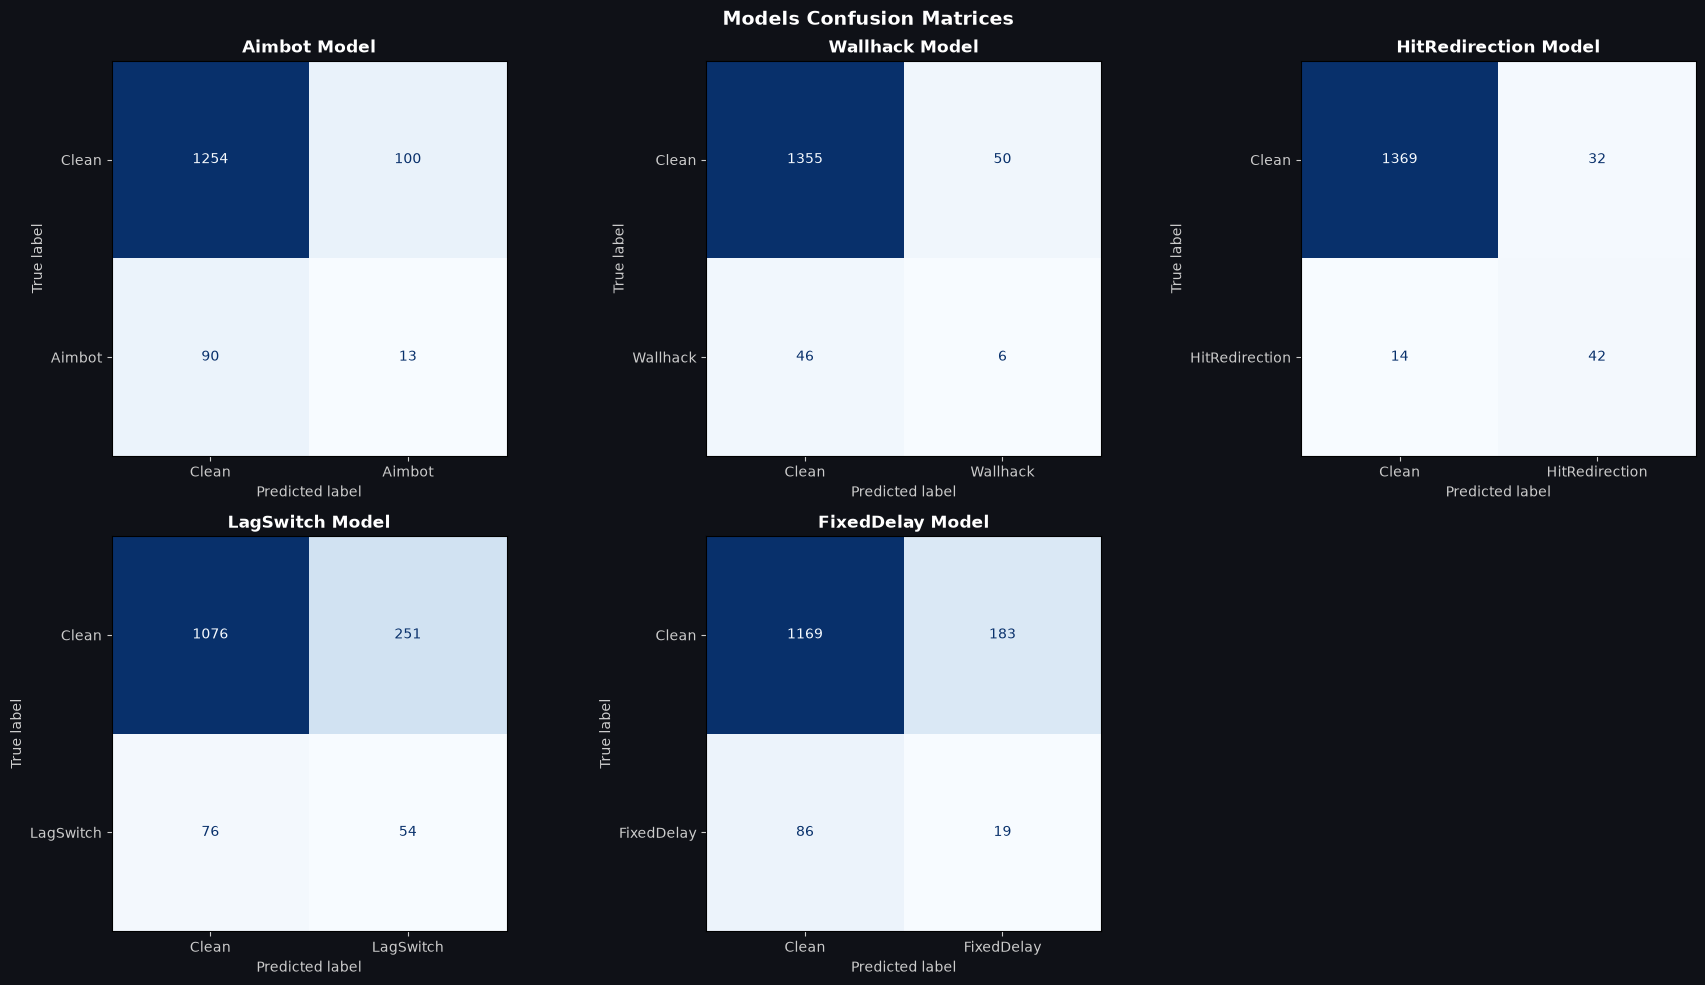

Plot saved as model_5_results.png 


In [8]:
BG      = '#1a1a2e'
TITLE_C = '#ffffff'
LABEL_C = '#cccccc'
GRID_C  = '#2a2a3a'
 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')
 
models = [
    (model_aimbot,    'label_aimbot',     'Aimbot',         FEATURE_COLS_BEHAVIORAL, axes[0,0]),
    (model_wallhack,  'label_wallhack',   'Wallhack',       FEATURE_COLS_BEHAVIORAL, axes[0,1]),
    (model_hitredir,  'label_hitredir',   'HitRedirection', FEATURE_COLS_BEHAVIORAL, axes[0,2]),
    (model_lagswitch, 'label_lagswitch',  'LagSwitch',      FEATURE_COLS_NETWORK,    axes[1,0]),
    (model_fixeddelay,'label_fixeddelay', 'FixedDelay',     FEATURE_COLS_NETWORK,    axes[1,1]),
]
 
for model, label_col, name, fcols, ax in models:
    ax.set_facecolor(BG)
    X_te = test_df[fcols].replace([np.inf,-np.inf],np.nan).fillna(0)
    y_te = test_df[label_col]
    y_pr = model.predict(X_te)
    cm   = confusion_matrix(y_te, y_pr)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Clean', name])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} Model', color=TITLE_C, fontweight='bold')
    ax.tick_params(colors=LABEL_C)
    ax.xaxis.label.set_color(LABEL_C)
    ax.yaxis.label.set_color(LABEL_C)
 
axes[1,2].set_visible(False)
 
fig.suptitle('Models Confusion Matrices',
             color=TITLE_C, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_5_results.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Plot saved as model_5_results.png ")

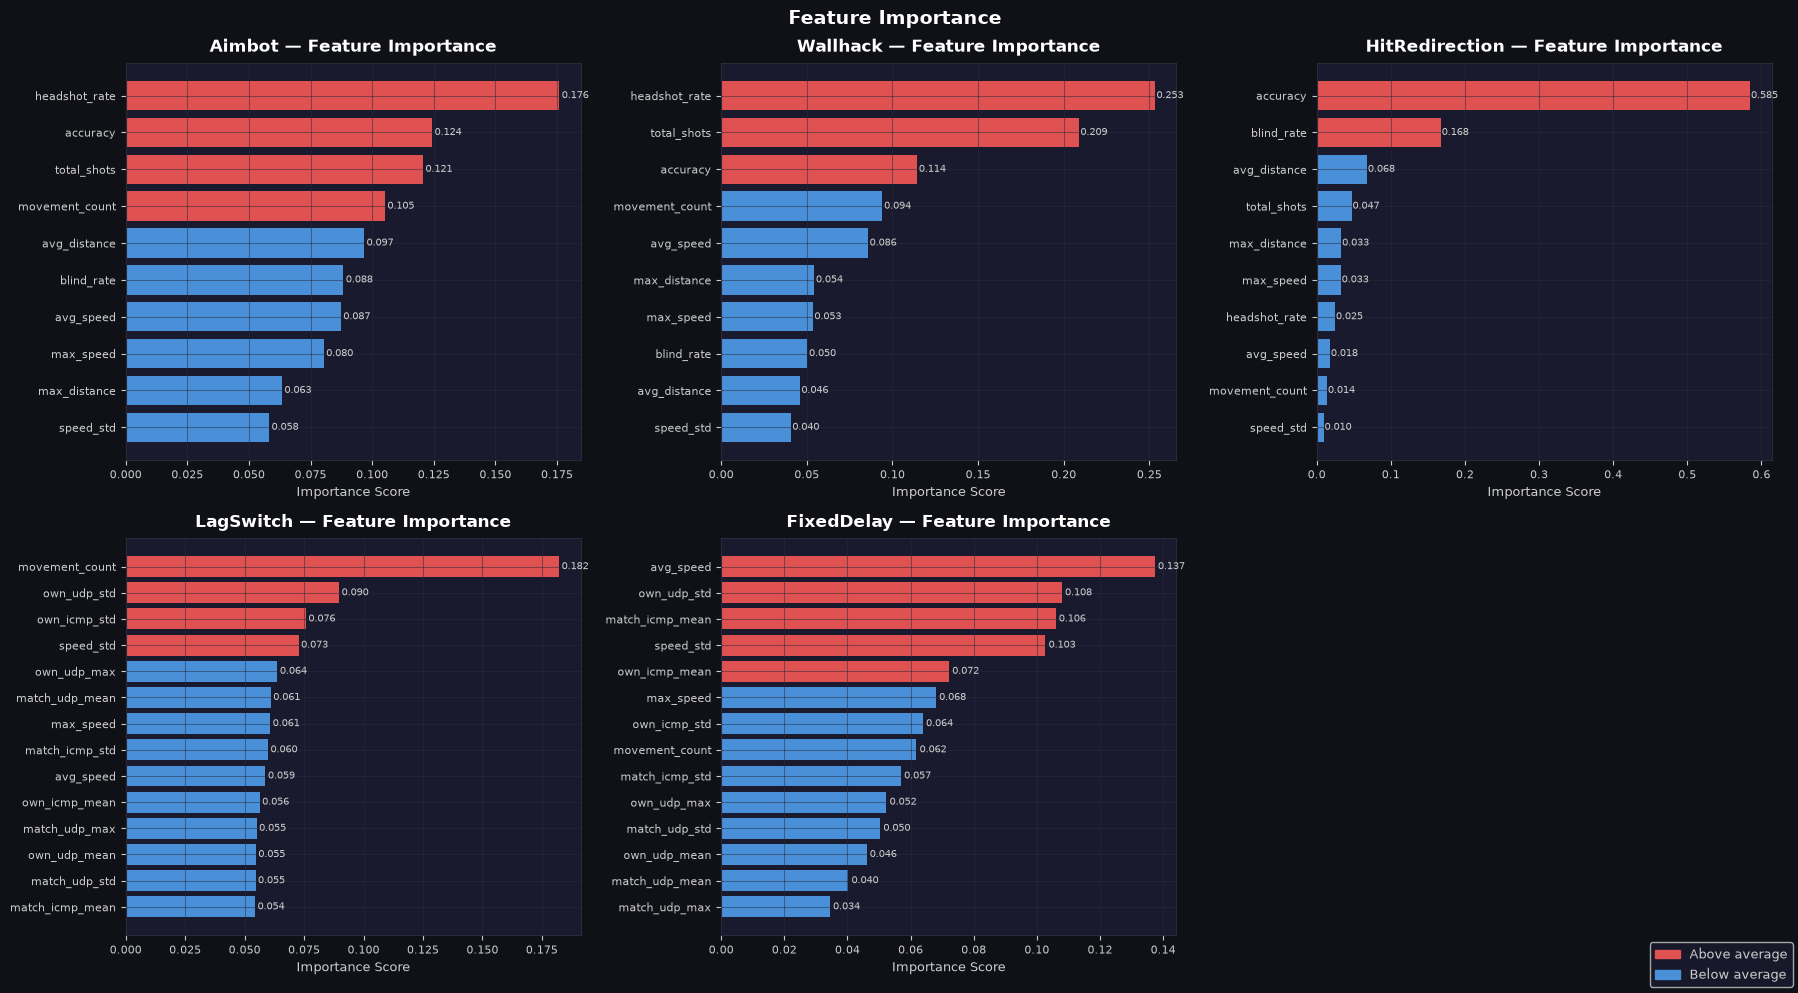

Feature importance saved 


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#0f1117')

BG      = '#1a1a2e'
TITLE_C = '#ffffff'
LABEL_C = '#cccccc'
GRID_C  = '#2a2a3a'

models_info = [
    (model_aimbot,     'Aimbot',         FEATURE_COLS_BEHAVIORAL, axes[0,0]),
    (model_wallhack,   'Wallhack',       FEATURE_COLS_BEHAVIORAL, axes[0,1]),
    (model_hitredir,   'HitRedirection', FEATURE_COLS_BEHAVIORAL, axes[0,2]),
    (model_lagswitch,  'LagSwitch',      FEATURE_COLS_NETWORK,    axes[1,0]),
    (model_fixeddelay, 'FixedDelay',     FEATURE_COLS_NETWORK,    axes[1,1]),
]

for model, name, fcols, ax in models_info:
    ax.set_facecolor(BG)

    imp = pd.Series(
        model.feature_importances_,
        index=fcols
    ).sort_values()

    colors = ['#e05252' if v > imp.mean() else '#4a90d9'
              for v in imp.values]

    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f'{name} — Feature Importance',
                 color=TITLE_C, fontweight='bold', pad=8)
    ax.tick_params(colors=LABEL_C, labelsize=8)
    ax.set_xlabel('Importance Score', color=LABEL_C, fontsize=9)
    ax.grid(True, color=GRID_C, alpha=0.5)
    for sp in ax.spines.values():
        sp.set_edgecolor(GRID_C)

    for i, (val, label) in enumerate(zip(imp.values, imp.index)):
        ax.text(val + 0.001, i, f'{val:.3f}',
                va='center', color=LABEL_C, fontsize=7)

axes[1,2].set_facecolor('#0f1117')
axes[1,2].set_visible(False)

red_p = mpatches.Patch(color='#e05252', label='Above average')
blu_p = mpatches.Patch(color='#4a90d9', label='Below average')
fig.legend(handles=[red_p, blu_p], fontsize=9,
           facecolor=BG, labelcolor=LABEL_C,
           loc='lower right')

fig.suptitle('Feature Importance',
             color=TITLE_C, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_5models.png', dpi=150,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("Feature importance saved ")

In [10]:
THRESHOLD = 0.5

def extract_features(ww, mm, pp_own, pp_all):
    total_shots   = len(ww)
    on_target     = ww['on_target'].sum()
    blind_shots   = ww['is_blind'].sum()
    head_shots    = (ww['bone']=='Head').sum()
    hits          = ww[ww['on_target']==True]
    avg_dist      = hits['distance'].mean() if len(hits)>0 else 0
    max_dist      = hits['distance'].max()  if len(hits)>0 else 0
    accuracy      = on_target/total_shots   if total_shots>0 else 0
    blind_rate    = blind_shots/total_shots  if total_shots>0 else 0
    headshot_rate = head_shots/total_shots   if total_shots>0 else 0
    movement_count= len(mm)

    if len(mm)>1:
        mm = mm.copy()
        mm['dx']    = mm['x'].diff()
        mm['dy']    = mm['y'].diff()
        mm['dz']    = mm['z'].diff()
        mm['dt']    = mm['timestamp'].diff().dt.total_seconds()
        mm['speed'] = np.sqrt(mm['dx']**2+mm['dy']**2+mm['dz']**2)/mm['dt']
        mm['speed'] = mm['speed'].replace([np.inf,-np.inf], np.nan)
        avg_speed   = mm['speed'].mean() if not mm['speed'].isna().all() else 0
        max_speed   = mm['speed'].max()  if not mm['speed'].isna().all() else 0
        speed_std   = mm['speed'].std()  if not mm['speed'].isna().all() else 0
    else:
        avg_speed = max_speed = speed_std = 0

    own_udp_mean  = pp_own['udp_ping'].mean()  if len(pp_own)>0 else 0
    own_udp_std   = pp_own['udp_ping'].std()   if len(pp_own)>0 else 0
    own_udp_max   = pp_own['udp_ping'].max()   if len(pp_own)>0 else 0
    own_icmp_mean = pp_own['icmp_ping'].mean() if len(pp_own)>0 else 0
    own_icmp_std  = pp_own['icmp_ping'].std()  if len(pp_own)>0 else 0

    match_udp_mean  = pp_all['udp_ping'].mean()  if len(pp_all)>0 else 0
    match_udp_std   = pp_all['udp_ping'].std()   if len(pp_all)>0 else 0
    match_udp_max   = pp_all['udp_ping'].max()   if len(pp_all)>0 else 0
    match_icmp_mean = pp_all['icmp_ping'].mean() if len(pp_all)>0 else 0
    match_icmp_std  = pp_all['icmp_ping'].std()  if len(pp_all)>0 else 0

    behavioral = pd.DataFrame([{
        'total_shots':   total_shots,
        'accuracy':      accuracy,
        'blind_rate':    blind_rate,
        'headshot_rate': headshot_rate,
        'avg_distance':  avg_dist,
        'max_distance':  max_dist,
        'movement_count':movement_count,
        'avg_speed':     avg_speed,
        'max_speed':     max_speed,
        'speed_std':     speed_std,
    }]).replace([np.inf,-np.inf], np.nan).fillna(0)

    network = pd.DataFrame([{
        'movement_count':  movement_count,
        'avg_speed':       avg_speed,
        'max_speed':       max_speed,
        'speed_std':       speed_std,
        'own_udp_mean':    own_udp_mean,
        'own_udp_std':     own_udp_std,
        'own_udp_max':     own_udp_max,
        'own_icmp_mean':   own_icmp_mean,
        'own_icmp_std':    own_icmp_std,
        'match_udp_mean':  match_udp_mean,
        'match_udp_std':   match_udp_std,
        'match_udp_max':   match_udp_max,
        'match_icmp_mean': match_icmp_mean,
        'match_icmp_std':  match_icmp_std,
    }]).replace([np.inf,-np.inf], np.nan).fillna(0)

    return behavioral, network


def merge_detections(detections_df, merge_gap=5):
    
    if len(detections_df) == 0:
        return pd.DataFrame()

    merged = []

    for player_id in detections_df['player_id'].unique():
        player_dets = detections_df[
            detections_df['player_id']==player_id
        ].sort_values('cheat_start').reset_index(drop=True)

        if len(player_dets) == 0:
            continue

        current_start = player_dets.iloc[0]['cheat_start']
        current_end   = player_dets.iloc[0]['cheat_end']

        for i in range(1, len(player_dets)):
            row = player_dets.iloc[i]
            gap = (row['cheat_start'] - current_end).total_seconds()

            if gap <= merge_gap:
                
                current_end = max(current_end, row['cheat_end'])
            else:
                
                merged.append({
                    'player_id':   player_id,
                    'cheat_start': current_start,
                    'cheat_end':   current_end,
                    'duration':    (current_end - current_start).total_seconds(),
                })
                current_start = row['cheat_start']
                current_end   = row['cheat_end']

        merged.append({
            'player_id':   player_id,
            'cheat_start': current_start,
            'cheat_end':   current_end,
            'duration':    (current_end - current_start).total_seconds(),
        })

    return pd.DataFrame(merged)


def predict_match(session, match):
    
    w     = weapon_df[(weapon_df['session']==session)&
                      (weapon_df['match']==match)].copy()
    m     = mov_df[(mov_df['session']==session)&
                   (mov_df['match']==match)].copy()
    p_all = ping_df[(ping_df['session']==session)&
                    (ping_df['match']==match)].copy()

    players = pd.concat([
        w[['player_id']],
        m[['player_id']]
    ]).dropna()['player_id'].unique()

    raw_detections = []

    for player_id in sorted(players):
        pw    = w[w['player_id']==player_id].copy()
        pm    = m[m['player_id']==player_id].copy().sort_values('timestamp')
        p_own = p_all[p_all['player_id']==player_id].copy()

        times = []
        if len(pw)>0: times += [pw['timestamp'].min(), pw['timestamp'].max()]
        if len(pm)>0: times += [pm['timestamp'].min(), pm['timestamp'].max()]
        if not times: continue

        player_start = min(times)
        player_end   = max(times)

        cheat_active = False
        cheat_start  = None

        t = player_start
        while t < player_end:
            t_end = t + pd.Timedelta(seconds=WINDOW_SIZE)

            ww    = pw[(pw['timestamp']>=t)&(pw['timestamp']<t_end)]
            mm    = pm[(pm['timestamp']>=t)&(pm['timestamp']<t_end)].copy()
            pp_own= p_own[(p_own['timestamp']>=t)&(p_own['timestamp']<t_end)]
            pp_all= p_all[(p_all['timestamp']>=t)&(p_all['timestamp']<t_end)]

            beh, net = extract_features(ww, mm, pp_own, pp_all)

            probs = {
                'Aimbot':         model_aimbot.predict_proba(
                                      beh[FEATURE_COLS_BEHAVIORAL])[0][1],
                'Wallhack':       model_wallhack.predict_proba(
                                      beh[FEATURE_COLS_BEHAVIORAL])[0][1],
                'HitRedirection': model_hitredir.predict_proba(
                                      beh[FEATURE_COLS_BEHAVIORAL])[0][1],
                'LagSwitch':      model_lagswitch.predict_proba(
                                      net[FEATURE_COLS_NETWORK])[0][1],
                'FixedDelay':     model_fixeddelay.predict_proba(
                                      net[FEATURE_COLS_NETWORK])[0][1],
            }

            any_cheat = any(prob >= THRESHOLD for prob in probs.values())

            if any_cheat and not cheat_active:
                cheat_active = True
                cheat_start  = t

            elif not any_cheat and cheat_active:
                cheat_active = False
                raw_detections.append({
                    'player_id':   int(player_id),
                    'cheat_start': cheat_start,
                    'cheat_end':   t,
                    'duration':    (t - cheat_start).total_seconds(),
                })
                cheat_start = None

            t += pd.Timedelta(seconds=STEP_SIZE)

        if cheat_active and cheat_start:
            raw_detections.append({
                'player_id':   int(player_id),
                'cheat_start': cheat_start,
                'cheat_end':   t,
                'duration':    (t - cheat_start).total_seconds(),
            })

    raw_df = pd.DataFrame(raw_detections)
    return merge_detections(raw_df, merge_gap=STEP_SIZE)

In [13]:
TEST_MATCHES = [
    ('Session_2', 'Match2'),
    ('Session_2', 'Match3'),
    ('Session_2', 'Match4'),
]

def merge_detections(detections_df, merge_gap=30):
    if len(detections_df) == 0:
        return pd.DataFrame()

    merged = []

    for player_id in detections_df['player_id'].unique():
        player_dets = detections_df[
            detections_df['player_id']==player_id
        ].sort_values('cheat_start').reset_index(drop=True)

        if len(player_dets) == 0:
            continue

        current_start = player_dets.iloc[0]['cheat_start']
        current_end   = player_dets.iloc[0]['cheat_end']

        for i in range(1, len(player_dets)):
            row = player_dets.iloc[i]
            gap = (row['cheat_start'] - current_end).total_seconds()

            if gap <= merge_gap:
                
                current_end = max(current_end, row['cheat_end'])
            else:
                
                merged.append({
                    'player_id':   player_id,
                    'cheat_start': current_start,
                    'cheat_end':   current_end,
                    'duration':    (current_end - current_start).total_seconds(),
                })
                current_start = row['cheat_start']
                current_end   = row['cheat_end']

        
        merged.append({
            'player_id':   player_id,
            'cheat_start': current_start,
            'cheat_end':   current_end,
            'duration':    (current_end - current_start).total_seconds(),
        })

    return pd.DataFrame(merged)


print("  Anti-cheat Detetion Result")
print("  Session_2: Match2 / Match3 / Match4")

total_detections = 0

for session, match in TEST_MATCHES:
    print(f"\n{'─'*60}")
    print(f"  {session} / {match}")
    print(f"{'─'*60}")

    # Get raw detections
    raw_results = predict_match(session, match)

    if len(raw_results) == 0:
        print(f"CLEAN — No cheating detected")
        continue

    results = merge_detections(raw_results, merge_gap=5)
    results = results.sort_values('cheat_start').reset_index(drop=True)
    total_detections += len(results)

    for i, r in results.iterrows():
        print(f"\n CHEAT DETECTED")
        print(f"  When     : {r['cheat_start'].strftime('%Y-%m-%d %H:%M:%S UTC')}")
        print(f"  Until    : {r['cheat_end'].strftime('%Y-%m-%d %H:%M:%S UTC')}")
        print(f"  Duration : {r['duration']:.0f} seconds")

    print(f"\n  Total in this match: {len(results)}")

print(f"\n{'='*60}")
print(f"  Total detections : {total_detections}")
print(f"  Detection complete")
print(f"{'='*60}")

  Anti-cheat Detetion Result
  Session_2: Match2 / Match3 / Match4

────────────────────────────────────────────────────────────
  Session_2 / Match2
────────────────────────────────────────────────────────────

 CHEAT DETECTED
  When     : 2026-02-26 12:27:57 UTC
  Until    : 2026-02-26 12:28:02 UTC
  Duration : 5 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:28:12 UTC
  Until    : 2026-02-26 12:34:12 UTC
  Duration : 360 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:28:27 UTC
  Until    : 2026-02-26 12:28:37 UTC
  Duration : 10 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:28:47 UTC
  Until    : 2026-02-26 12:29:07 UTC
  Duration : 20 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:29:31 UTC
  Until    : 2026-02-26 12:30:36 UTC
  Duration : 65 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:29:37 UTC
  Until    : 2026-02-26 12:29:57 UTC
  Duration : 20 seconds

 CHEAT DETECTED
  When     : 2026-02-26 12:29:46 UTC
  Until    : 2026-02-26 12:30:31 UTC
  Durati

In [12]:
cheat_counts = cheat_df[cheat_df['start']==True]['cheat_type'].value_counts()
total = cheat_counts.sum()

print("=" * 45)
print("  CHEAT FREQUENCY — Full Dataset")
print("=" * 45)

for cheat, count in cheat_counts.items():
    pct  = count / total * 100
    bar  = 'I' * int(pct / 2)
    print(f"  {cheat:<16}: {count:>3} ({pct:>5.1f}%) {bar}")

print(f"{'─'*45}")
print(f"  {'Total':<16}: {total:>3} (100.0%)")
print("=" * 45)

  CHEAT FREQUENCY — Full Dataset
  LagSwitch       :  91 ( 40.3%) IIIIIIIIIIIIIIIIIIII
  FixedDelay      :  50 ( 22.1%) IIIIIIIIIII
  Aimbot          :  42 ( 18.6%) IIIIIIIII
  HitRedirection  :  23 ( 10.2%) IIIII
  Wallhack        :  20 (  8.8%) IIII
─────────────────────────────────────────────
  Total           : 226 (100.0%)
